# 04. GDPR Compliance

## 📚 Learning Objectives

By completing this notebook, you will:
- Map GDPR requirements to AI systems
- Implement compliance-oriented practices
- Address rights, consent, and data minimization

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 08 "Exploring the Data Generation Process Using Python and Pandas" — where data comes from decides which rights attach to it.

**Used later in:** Course 10 (AIAT 124) — Unit 4, lesson 04 "Applying AI Regulatory Guidelines (GDPR) in Model Development".

---


# 04. GDPR Compliance

## 🚨 THE PROBLEM: We Need Regulatory Compliance

**Remember the limitation from the previous notebook?**

We learned differential privacy with mathematical guarantees. But we discovered:

**How do we ensure our AI systems comply with privacy regulations like GDPR?**

**The Problem**: Real-world AI systems must also:
- ❌ **Comply with regulations** (GDPR, CCPA, etc.)
- ❌ **Implement data subject rights** (right to access, deletion, etc.)
- ❌ **Document privacy practices** (privacy impact assessments)
- ❌ **Meet legal requirements** (consent, data minimization, etc.)

**We've learned:**
- ✅ How to use basic data protection (Notebook 1)
- ✅ How to use advanced privacy technologies (Notebook 2)
- ✅ How to use differential privacy (Notebook 3)
- ✅ Privacy techniques and guarantees

**But we haven't learned:**
- ❌ How to **comply with GDPR** requirements
- ❌ How to **implement data subject rights**
- ❌ How to **document privacy practices**
- ❌ How to **meet legal requirements**

**We need GDPR compliance practices** to:
1. Implement data subject rights
2. Document privacy practices
3. Meet legal requirements
4. Ensure regulatory compliance

**This notebook solves that problem** by teaching you GDPR compliance requirements and practices!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Data Protection** - Understanding basic protection
- ✅ **Example 2: Privacy Technologies** - Understanding PETs
- ✅ **Example 3: Differential Privacy** - Understanding privacy guarantees
- ✅ **Basic Python knowledge**: Functions, data manipulation

**If you haven't completed these**, you might struggle with:
- Understanding why regulatory compliance matters
- Knowing GDPR requirements
- Understanding data subject rights

---

## 🔗 Where This Notebook Fits

**This is the FOURTH example in Unit 3** - it teaches you regulatory compliance!

**Why this example FOURTH?**
- **Before** you can ensure compliance, you need privacy techniques (Examples 1-3)
- **Before** you can implement secure development, you need compliance
- **Before** you can deploy systems, you need regulatory compliance

**Builds on**: 
- 📓 Example 1: Data Protection (basic protection strategies)
- 📓 Example 2: Privacy Technologies (advanced PETs)
- 📓 Example 3: Differential Privacy (privacy guarantees)

**Leads to**: 
- 📓 Example 5: Secure Development (secure coding practices)

**Why this order?**
1. GDPR compliance provides **regulatory framework** (needed for legal operation)
2. GDPR compliance teaches **data subject rights** (critical for users)
3. GDPR compliance shows **documentation practices** (essential for accountability)

---

## The Story: Legal Compliance

Imagine you're a company processing personal data. **Before** GDPR compliance, you might process data without proper consent or documentation (legal risk!). **After** implementing GDPR compliance, you have proper consent, data subject rights, and documentation - legal compliance!

Same with AI: **Before** we have privacy techniques but may not comply with regulations, now we learn GDPR compliance - implement data subject rights, document practices, meet legal requirements! **After** GDPR compliance, we have legally compliant AI systems!

---

## Why GDPR Compliance Matters

GDPR compliance is essential for ethical AI:
- **Legal Requirement**: Must comply with privacy regulations
- **Data Subject Rights**: Respect individuals' privacy rights
- **Trust**: Build user confidence through compliance
- **Accountability**: Document privacy practices
- **Risk Mitigation**: Avoid legal penalties and fines

## Learning Objectives
1. Understand key GDPR principles
2. Learn data subject rights
3. Implement GDPR compliance practices
4. Document privacy practices
5. Create compliance checklists
6. Understand privacy by design

## 📌 The case: the Court of Justice decided that the *score* is the decision

For years the standard answer to GDPR Article 22 was a shrug. Article 22 gives people a
right not to be subject to a decision "based solely on automated processing", and every
vendor of a scoring system gave the same reply: *we do not decide anything — we produce a
number, and a human decides*.

**Case C-634/21, SCHUFA Holding ("Scoring"), judgment of 7 December 2023.** SCHUFA is
Germany's largest credit reference agency. OQ was refused credit by a third party that had
drawn on a SCHUFA score. SCHUFA argued the score was not a decision.

The Court of Justice of the European Union disagreed. Where a third party **draws strongly
on** such a score to grant or refuse a contract, the automated production of the score is
itself an **automated individual decision within the meaning of Article 22(1)** — and the
obligations land on the **agency that computed it**, not only on the bank that acted on it.

Read that as an engineer. The team that trains the model does not escape the law by shipping
a probability and letting a caseworker press the button. If the caseworker follows the score,
the score is the decision, and the people who built it owe the data subject meaningful
information about the logic involved, a right to contest, and human intervention.

**The WHY — what goes wrong without compliance work.** GDPR is not a document you read once.
It is a set of duties that have to be **implemented as code and process**: a lawful basis
recorded, a purpose declared, unused personal columns dropped, an access request answerable
within a month, an erasure that actually erases. Teams that skip this discover their gaps at
the worst moment. The Dutch tax administration ran a childcare-benefits fraud model that
processed applicants' nationality; roughly **26,000 families** were wrongly accused, the
Dutch DPA fined the responsible minister **€2.75 million** on 7 December 2021, and the entire
Rutte III cabinet resigned over the affair on **15 January 2021**. You are about to run
compliance as code on this course's own screening system, and it will not pass.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- GDPR Article 5 principles and the data-subject rights, encoded as Python data.
- The **real Titanic passenger manifest** (`Course 04/datasets/raw/titanic.csv`) -
  used to *measure* one duty rather than declare it: how many personal columns
  the file carries that the model of Units 2-4 never uses.

**Outputs:** What you'll see when you run the cells

- The principles and rights printed as a checklist.
- A measured data-minimization finding, and a compliance audit of the course's
  own screening system with a score and a remediation list.

---


## Part 1: Mapping GDPR to AI Systems

The GDPR (EU General Data Protection Regulation, in force since 2018) sets seven core
principles (Art. 5) and grants data subjects concrete rights (Art. 12-22). Below we encode
them as data and *check an AI system profile against them* - compliance as code.

In [1]:
# Why encode the law as data: once principles and rights are dicts,
# we can loop over them, build checklists, and audit systems programmatically.

# Step 1: Encode GDPR principles and data-subject rights

print("="*80)
print("📜 GDPR PRINCIPLES AND RIGHTS (encoded as data)")
print("="*80)

# The seven processing principles of GDPR Article 5, in plain English.
gdpr_principles = {
    'lawfulness_fairness_transparency': 'Valid legal basis; no deception; clear info',
    'purpose_limitation': 'Use data only for the declared purpose',
    'data_minimization': 'Collect only what the purpose requires',
    'accuracy': 'Keep personal data accurate and up to date',
    'storage_limitation': 'Delete/anonymize when no longer needed',
    'integrity_confidentiality': 'Protect data (security, encryption, access control)',
    'accountability': 'Be able to DEMONSTRATE compliance (records, DPIAs)',
}
# The rights every person holds over their data - each maps to a feature
# your AI system must actually implement (access, deletion, human review...).
data_subject_rights = {
    'access': 'Get a copy of their data (Art. 15)',
    'rectification': 'Correct inaccurate data (Art. 16)',
    'erasure': '"Right to be forgotten" (Art. 17)',
    'portability': 'Receive data in machine-readable form (Art. 20)',
    'object': 'Object to processing incl. profiling (Art. 21)',
    'not_solely_automated': 'Human involvement in significant automated decisions (Art. 22)',
}
print("\nPrinciples (Art. 5):")
for k, v in gdpr_principles.items():
    print(f"  - {k}: {v}")
print("\nData-subject rights:")
for k, v in data_subject_rights.items():
    print(f"  - {k}: {v}")
print("\nArt. 22 is the one that bites AI hardest: significant decisions may not be")
print("based SOLELY on automated processing - one more reason for human-in-the-loop.")

📜 GDPR PRINCIPLES AND RIGHTS (encoded as data)

Principles (Art. 5):
  - lawfulness_fairness_transparency: Valid legal basis; no deception; clear info
  - purpose_limitation: Use data only for the declared purpose
  - data_minimization: Collect only what the purpose requires
  - accuracy: Keep personal data accurate and up to date
  - storage_limitation: Delete/anonymize when no longer needed
  - integrity_confidentiality: Protect data (security, encryption, access control)
  - accountability: Be able to DEMONSTRATE compliance (records, DPIAs)

Data-subject rights:
  - access: Get a copy of their data (Art. 15)
  - rectification: Correct inaccurate data (Art. 16)
  - erasure: "Right to be forgotten" (Art. 17)
  - portability: Receive data in machine-readable form (Art. 20)
  - object: Object to processing incl. profiling (Art. 21)
  - not_solely_automated: Human involvement in significant automated decisions (Art. 22)

Art. 22 is the one that bites AI hardest: significant decisions may

In [2]:
# Why: compliance is testable - express each GDPR duty as a boolean check
# and any system profile can be audited in one function call.

# Step 2: A compliance check for an AI system profile

def check_gdpr_compliance(system):
    """Check an AI system profile dict against GDPR-oriented requirements.
    Returns (met, gaps) lists. A teaching checklist - not legal advice."""
    checks = [
        ('lawfulness',      system.get('legal_basis') is not None,
         'Define a legal basis (consent, contract, legitimate interest...)'),
        ('purpose_limitation', system.get('purpose_documented', False),
         'Document the specific purpose of processing'),
        ('data_minimization', not system.get('collects_unused_fields', True),
         'Stop collecting fields the model does not need'),
        ('storage_limitation', system.get('retention_days') is not None
                               and system['retention_days'] <= 365,
         'Set a retention period (<= 365 days here) and enforce deletion'),
        ('security',        system.get('encrypted_at_rest', False),
         'Encrypt personal data at rest (see Notebook 1!)'),
        ('subject_access',  system.get('supports_access_requests', False),
         'Implement data-subject access requests'),
        ('erasure',         system.get('supports_erasure', False),
         'Implement the right to erasure'),
        ('human_oversight', system.get('human_review_for_decisions', False),
         'Add human review for significant automated decisions (Art. 22)'),
    ]
    met = [(name, fix) for name, ok, fix in checks if ok]
    gaps = [(name, fix) for name, ok, fix in checks if not ok]
    return met, gaps

# --- The system we audit: the real course system, profiled honestly ---
# WHY measure instead of declare: data minimization is the one GDPR duty you can
# CHECK against the data itself. We compare the personal columns the real file
# contains against the ones the model actually consumes, and let the difference
# speak. The remaining fields are policy facts about the course demo, stated as
# what they are - declarations, which is exactly what an auditor is given.
import pandas as pd

manifest = pd.read_csv('../../../Course 04/datasets/raw/titanic.csv')
MODEL_FEATURES = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex']  # what Units 2-4 use
personal_columns = [c for c in manifest.columns if c not in ('Survived',)]
unused_personal = [c for c in personal_columns if c not in MODEL_FEATURES]

print("DATA MINIMIZATION CHECK (measured on the real file, not declared)")
print("-" * 80)
print(f"  columns in the dataset          : {len(manifest.columns)} {list(manifest.columns)}")
print(f"  columns the model actually uses : {len(MODEL_FEATURES)} {MODEL_FEATURES}")
print(f"  personal fields carried but unused: {len(unused_personal)} {unused_personal}")
print("  -> Every unused personal field is data you hold, must secure, must")
print("     disclose on an access request, and must delete on erasure - for no")
print("     modelling benefit. That is what 'minimization' means in practice.")

# Profile of the screening system built across Units 2-4 (the Titanic survival
# classifier). The measured field comes from the check above; the rest are
# declared facts about how the course demo was actually run.
screening_system = {
    'name': 'screening-rf-v1.0 (Units 2-4 course demo)',
    'legal_basis': 'legitimate_interest',      # declared
    'purpose_documented': True,                # declared: purpose stated in Unit 2
    'collects_unused_fields': len(unused_personal) > 0,   # MEASURED above
    'retention_days': 730,                     # declared: raw manifest kept 2 years (!)
    'encrypted_at_rest': True,                 # declared: see Notebook 01
    'supports_access_requests': True,          # declared
    'supports_erasure': False,                 # declared (!)
    'human_review_for_decisions': True,        # declared: HITL routing, Unit 4 Nb. 05
}

# Run the audit and report what passes, what fails, and how to fix each gap.
met, gaps = check_gdpr_compliance(screening_system)
print("\n" + "="*80)
print(f"GDPR COMPLIANCE CHECK: {screening_system['name']}")
print("="*80)
print(f"\n\u2705 Requirements met ({len(met)}/8):")
for name, _ in met:
    print(f"   - {name}")
print(f"\n\u274C Gaps found ({len(gaps)}/8) - with remediation:")
for name, fix in gaps:
    print(f"   - {name}: {fix}")
score = len(met) / 8
print(f"\nCompliance score: {score:.0%} -> {'ship it' if score == 1 else 'NOT ready for production'}")
print("\nNotice which gaps are cheap to close on paper and which are real work:")
print(f"  - minimization: drop the {len(unused_personal)} unused personal fields at load time (one line)")
print("  - erasure: needs a delete path through the dataset AND any retrained model")
print("  - retention: 730 days is a choice someone made; GDPR asks you to justify it")


DATA MINIMIZATION CHECK (measured on the real file, not declared)
--------------------------------------------------------------------------------
  columns in the dataset          : 12 ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
  columns the model actually uses : 6 ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex']
  personal fields carried but unused: 5 ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked']
  -> Every unused personal field is data you hold, must secure, must
     disclose on an access request, and must delete on erasure - for no
     modelling benefit. That is what 'minimization' means in practice.

GDPR COMPLIANCE CHECK: screening-rf-v1.0 (Units 2-4 course demo)

✅ Requirements met (5/8):
   - lawfulness
   - purpose_limitation
   - security
   - subject_access
   - human_oversight

❌ Gaps found (3/8) - with remediation:
   - data_minimization: Stop collecting fields the model does not need
  

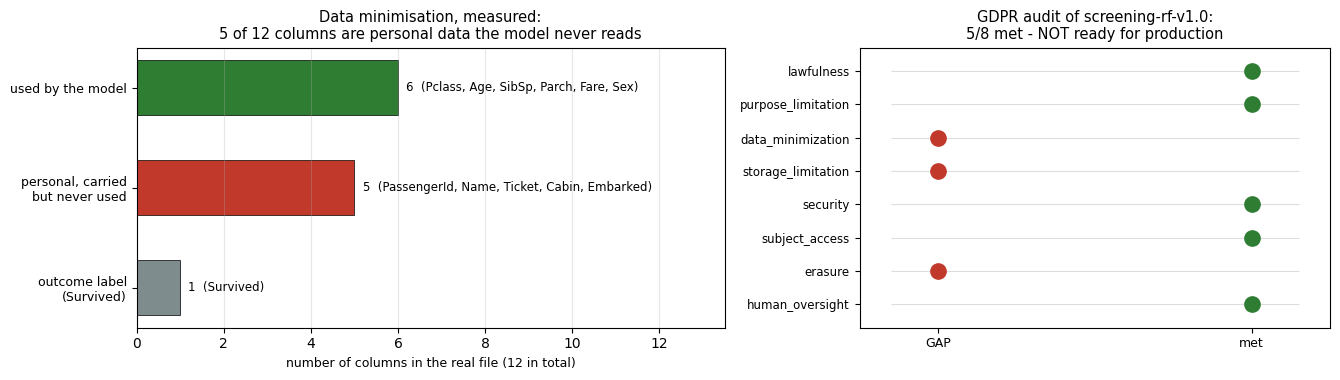

In [3]:
# WHY a picture here: a compliance report is read by people who will not read
# 40 lines of printed output. Both halves of the audit above turn into one board:
# what the file actually carries, and which duties the system actually meets.

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13.5, 3.9), gridspec_kw={'width_ratios': [1.25, 1]})

# --- Left: data minimisation, counted on the real file ---
categories = ['used by the model', 'personal, carried\nbut never used',
              'outcome label\n(Survived)']
counts = [len(MODEL_FEATURES), len(unused_personal), 1]
contents = [', '.join(MODEL_FEATURES), ', '.join(unused_personal), 'Survived']
ax = axes[0]
ys = np.arange(3)[::-1]
ax.barh(ys, counts, color=['#2e7d32', '#c0392b', '#7f8c8d'], height=0.55,
        edgecolor='black', linewidth=0.5)
for v, yy, names in zip(counts, ys, contents):
    ax.annotate(f'{v}  ({names})', (v, yy), xytext=(6, 0), textcoords='offset points',
                va='center', fontsize=8.5)
ax.set_yticks(ys); ax.set_yticklabels(categories, fontsize=9)
ax.set_xlim(0, len(manifest.columns) + 1.5)
ax.set_xlabel(f'number of columns in the real file ({len(manifest.columns)} in total)', fontsize=9)
ax.set_title('Data minimisation, measured:\n'
             f'{len(unused_personal)} of {len(manifest.columns)} columns are personal data '
             'the model never reads', fontsize=10.5)
ax.grid(axis='x', alpha=0.3)

# --- Right: the audit itself, one row per GDPR duty ---
CHECK_ORDER = ['lawfulness', 'purpose_limitation', 'data_minimization', 'storage_limitation',
               'security', 'subject_access', 'erasure', 'human_oversight']
passed = {name for name, _ in met}
assert passed | {name for name, _ in gaps} == set(CHECK_ORDER)  # no check silently dropped
ax = axes[1]
ys = np.arange(len(CHECK_ORDER))[::-1]
for name, yy in zip(CHECK_ORDER, ys):
    ok = name in passed
    ax.hlines(yy, -0.15, 1.15, color='#dddddd', lw=0.8, zorder=0)  # guide line, not data
    ax.plot([1 if ok else 0], [yy], 'o', markersize=11,
            color='#2e7d32' if ok else '#c0392b')
ax.set_yticks(ys); ax.set_yticklabels(CHECK_ORDER, fontsize=8.5)
ax.set_xticks([0, 1]); ax.set_xticklabels(['GAP', 'met'], fontsize=9)
ax.set_xlim(-0.25, 1.25); ax.set_ylim(-0.7, len(CHECK_ORDER) - 0.3)
ax.set_title(f"GDPR audit of {screening_system['name'].split(' (')[0]}:\n"
             f"{len(met)}/{len(met) + len(gaps)} met - "
             f"{'ready' if not gaps else 'NOT ready for production'}", fontsize=10.5)

plt.tight_layout()
plt.show()


**Read the board.**

*Left* — the real file, counted rather than described. Six columns feed the model (green);
**five** are personal data the model never reads (red) — `PassengerId`, `Name`, `Ticket`,
`Cabin`, `Embarked`; one is the outcome label. The red bar is the data-minimisation finding:
five fields that must be secured, disclosed on every access request and deleted on every
erasure request, for **zero** modelling benefit. The bar is nearly as long as the green one.

*Right* — the audit, one dot per GDPR duty. A dot on the right is a duty met; a dot on the
left is a gap. Three sit on the left: **data_minimization** (proved by the red bar next to
it), **storage_limitation** (the raw manifest is kept 730 days), and **erasure** (there is no
delete path). Five sit on the right. **5 of 8 — the system does not pass.**

**What it proves:** compliance is not a document, it is a state of the system that can be
measured and drawn. Note also which gap is cheap and which is not: the red bar on the left is
closed by one `usecols=` at load time, while erasure needs a delete path through the dataset
*and* through every model already trained on it.


## 💬 Discuss

Your own run measured the data-minimisation duty rather than asserting it: the file carries
**12 columns**, the model uses **6**, and **5 personal fields** (`PassengerId`, `Name`,
`Ticket`, `Cabin`, `Embarked`) are held and never used.

1. **Delete them, then.** Every unused personal field must be secured, disclosed on an access
   request, and erased on request — for zero modelling benefit. So why does every
   organisation you have ever seen keep them? Give the honest business reason ("we might need
   it later", "the join key lives there", "nobody owns the deletion"), then write the policy
   sentence that would actually get them dropped. Would you sign it if it were your
   engineering team that has to implement it?
2. **Does the human in your loop count?** SCHUFA says a score is the decision when the human
   draws strongly on it. Take Unit 4's HITL routing: **47 %** of cases automated at
   threshold 0.9, the rest sent to a reviewer who sees the model's probability. Is that
   reviewer exercising human judgement, or rubber-stamping a score? What would you have to
   measure to tell the difference — and would you be comfortable if the regulator ran that
   measurement instead of you?
3. **Which regime binds you?** GDPR applies to personal data of people in the EU. Saudi
   Arabia's **PDPL** (Royal Decree M/19, 2021, amended M/148 in 2023, in force from
   September 2023 with full enforcement from 14 September 2024, supervised by SDAIA) applies
   to processing the personal data of people in the Kingdom, wherever the processor sits. A
   Riyadh-based team serving customers in both must satisfy both. Where do the two regimes
   pull in different directions — think about cross-border transfer, and about consent —
   and would you build one pipeline to the stricter standard, or two?


---

## 🚫 When GDPR Compliance Hits a Limitation

### The Limitation We Discovered

We've learned GDPR compliance requirements and practices. **But there's still a challenge:**

**How do we build secure AI systems that protect against attacks and vulnerabilities?**

GDPR compliance works well when:
- ✅ We comply with privacy regulations
- ✅ We implement data subject rights
- ✅ We document privacy practices

**But secure AI systems also need:**
- ❌ **Security measures** against attacks (adversarial, data poisoning)
- ❌ **Vulnerability management** (identify and fix security issues)
- ❌ **Secure coding practices** (prevent security bugs)
- ❌ **Security testing** (penetration testing, security audits)

### Why This Is a Problem

When we have privacy compliance but not security:
- Our systems may be vulnerable to attacks
- Adversarial examples may fool our models
- Data poisoning may corrupt our training data
- Security vulnerabilities may expose sensitive data

### The Solution: Secure Development

We need **secure development practices** to:
1. Protect against adversarial attacks
2. Manage security vulnerabilities
3. Implement secure coding practices
4. Test for security issues

**This is exactly what we'll learn in the next notebook: Secure Development!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to use basic data protection (Notebook 1)
- ✅ How to use advanced privacy technologies (Notebook 2)
- ✅ How to use differential privacy (Notebook 3)
- ✅ How to ensure GDPR compliance (This notebook!)
- ✅ **The limitation**: We need secure development practices!

**Next notebook**: `05_secure_development.ipynb`
- Learn about security vulnerabilities in AI
- Understand adversarial attacks
- Implement secure coding practices
- Build secure AI systems

## ⚠️ Where this breaks

- **A compliance checklist is a *necessary* condition, never a sufficient one.** The Dutch
  tax administration had procedures, lawyers and a DPO. It still wrongly accused about
  26,000 families, because the harm was in what the model was *for* and what it fed on, not
  in a missing checkbox. A boolean audit function like the one you just wrote proves the
  artefacts exist; it cannot read them.
- **The hard duties are the ones that resist automation.** `data_minimization` is measurable
  in three lines, as you saw. "Lawfulness, fairness and transparency" is a legal judgement
  about a specific processing purpose in a specific context, and no `dict` of booleans
  decides it. Beware a compliance score of 75 % that is 100 % on the easy half.
- **Erasure is much harder than deleting a row.** Article 17 reaches backups, logs,
  downstream copies, analytics warehouses — and the **model**, if it memorised the record.
  Machine unlearning is an open research problem, not a feature you can switch on, and a
  retrain may be the only honest answer.
- **The law moves and this notebook is a snapshot.** SCHUFA reinterpreted a 2016 regulation
  in 2023. The EU AI Act (Regulation (EU) 2024/1689) layers new duties on top from 2025–2027,
  and enforcement practice shifts every year. Treat everything here as a starting map and a
  vocabulary — never as legal advice, and never as current without checking.
- **Compliance is not ethics.** A system can be perfectly lawful and still be the wrong thing
  to build. Unit 1 is where that question lives; this notebook only tells you whether you may
  proceed, not whether you should.

**The cheaper alternative, and the one that actually reduces risk:** collect less. Every
field you never store needs no lawful basis, appears in no access request, cannot be
breached, and cannot be erased incorrectly. Data minimisation is the only control in the
whole regulation that makes the other twelve easier.


## 📚 References

1. European Parliament & Council (2016). *Regulation (EU) 2016/679 — General Data Protection Regulation (GDPR)*. <https://gdpr-info.eu/>
2. Wachter, S., Mittelstadt, B. & Russell, C. (2018). *Counterfactual Explanations without Opening the Black Box: Automated Decisions and the GDPR*. Harvard Journal of Law & Technology, 31(2). <https://arxiv.org/abs/1711.00399>
3. European Parliament & Council (2024). *Regulation (EU) 2024/1689 — the EU AI Act*. <https://digital-strategy.ec.europa.eu/en/policies/regulatory-framework-ai>
4. Guldimann, P., Spiridonov, A., Staab, R., Jovanovic, N., Vero, M., et al. (2024). *COMPL-AI Framework: A Technical Interpretation and LLM Benchmarking Suite for the EU Artificial Intelligence Act*. arXiv:2410.07959. <https://arxiv.org/abs/2410.07959> (the same "compliance as code" move as this notebook, carried out on the AI Act and run against 12 LLMs)
5. Staufer, D. (2025). *What Should LLMs Forget? Quantifying Personal Data in LLMs for Right-to-Be-Forgotten Requests*. arXiv:2507.11128. <https://arxiv.org/abs/2507.11128> (Article 17 against a trained model: measuring which personal facts a model memorised)
